<a href="https://colab.research.google.com/github/AhmadEgbaria1/machine-learning/blob/main/machine%20learning_assesment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducrtion to Machine Learning: Assignment #2
## Submission date: 19\05\2025, 23:59.
### Topics:
- Linear Regression
- Perceptron
- Logistic Regression
- SVM

Submitted by:

 **Student 1 Sham Abo Shtya 322857574

 **Student 2 Ahmad Agbaria 212352504

**Assignment Instruction:**

· Submissions in pairs only.

· Try to keep the code as clean, concise, and short as possible

· If you wish to work in your IDE, you can, but you **must**,  insert the script back to the matching cells of the notebook and run the code. <br/>Only the notebook will be submitted in moodle (in `.ipynb` format).

· <font color='red'>Please write your answers to question in red</font>.

**Important:** All plots, results and outputs should be included in the notebook as the cells' outputs (run all cells and do not clear the output). <br/>

**Important:** Your submission must be entirely your own. Any attempts of plagiarism (including ChatGPT) will lead to grade 0 and disciplinary actions.


## Question 1 - Linear Regression
You are requested to predict energy efficiency based on building attributes, such as wall area and glazing area.
The dataset consists of 8 continious features and **Two** outputs - Heat & Cool loadings.
You can read more about the dataset <a href='https://archive.ics.uci.edu/dataset/242/energy+efficiency'>here</a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split

Load data from https://sharon.srworkspace.com/ml/datasets/hw3/ENB2012_data.csv

In [ ]:
df = pd.read_csv('https://sharon.srworkspace.com/ml/datasets/hw3/ENB2012_data.csv')
df.head(3)

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33


Divide the data into 85% train and 15% test with random_state=21.



In [ ]:
# According to the dataset description:Columns 0–7 are the continuous building attributes and columns 8 and 9 are the outputs.
X = df.iloc[:, 0:8]
y = df.iloc[:, 8:10]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.85,
    random_state=21
)

# 3. Check sizes
print(f"Full dataset: {X.shape[0]} samples")
print(f"Train set:     {X_train.shape[0]} samples")
print(f"Test set:      {X_test.shape[0]} samples")


Full dataset: 768 samples
Train set:     652 samples
Test set:      116 samples


Define sklearn's linear regression, fit the train and save both train and test MSEs (by appending to results['Linear']). <br/>
DO NOT use "score" method of sklearn - we didn't learn about it and it does not measure MSE.

In [ ]:
results = {'Linear': [], 'Ridge': [], 'Lasso': []}

from sklearn.metrics import mean_squared_error

# Define and fit
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on train and test
y_train_pred = lr.predict(X_train)
y_test_pred  = lr.predict(X_test)

# Compute MSEs
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test,  y_test_pred)

# Save both in results['Linear']
results['Linear'].extend([mse_train, mse_test])

print(f"Train MSE: {mse_train:.3f}   Test MSE: {mse_test:.3f}")


Train MSE: 9.629   Test MSE: 7.684


**Show the correlation matrix of the train data. Should we do something?**
I see a strong correlation between features X2-Surface Area and X4-Roof Area (0.885258≈ 1) ,and this is intuitive because larger buildings tend to have larger roofs.
As we've seen in the lecture, a strong correlation can cause the coefficients to be very large, and they will cancel each other to achieve a good RSS.
So we need to use methods like Ridge and Lasso to shrink coefficients for correlated features, stabilizing our model.

In [ ]:
corr_matrix = X_train.corr()
print(corr_matrix)


          X1        X2        X3        X4        X5        X6        X7  \
X1  1.000000 -0.991887 -0.212095 -0.874242  0.830204  0.001159  0.008573   
X2 -0.991887  1.000000  0.205696  0.885258 -0.860425  0.000052 -0.010136   
X3 -0.212095  0.205696  1.000000 -0.273060  0.265704 -0.017172  0.024450   
X4 -0.874242  0.885258 -0.273060  1.000000 -0.972093  0.008212 -0.021584   
X5  0.830204 -0.860425  0.265704 -0.972093  1.000000 -0.004281  0.020553   
X6  0.001159  0.000052 -0.017172  0.008212 -0.004281  1.000000 -0.009887   
X7  0.008573 -0.010136  0.024450 -0.021584  0.020553 -0.009887  1.000000   
X8  0.015001 -0.015781  0.018908 -0.024499  0.029060  0.009963  0.237641   

          X8  
X1  0.015001  
X2 -0.015781  
X3  0.018908  
X4 -0.024499  
X5  0.029060  
X6  0.009963  
X7  0.237641  
X8  1.000000  


For both ridge and lasso, tune the best $\lambda$.
- For ridge, $\lambda\in \text{np.arange}(0.1, 1, 0.1)$.
- For lasso, $\lambda\in \text{np.logspace}(-4, -2, 20)$

For lasso, use `max_iter=5000`, as there is no close formula and convegence is not guranteeed.

Best Ridge α: 0.4
Best Lasso α: 0.004832930238571752


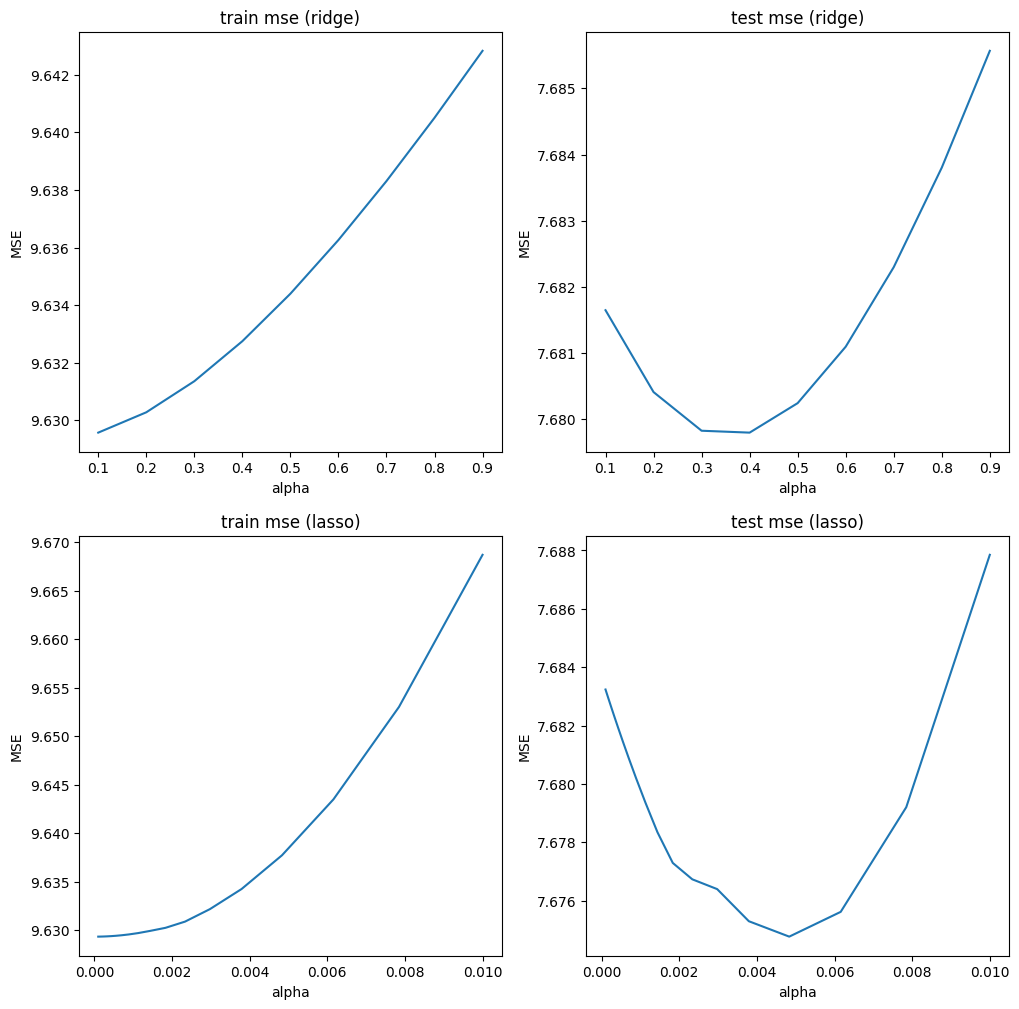

In [ ]:
# pre-process data, if needed
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
X_tr = scaler.transform(X_train)
X_te = scaler.transform(X_test)

######### RIDGE #########

alphas = np.arange(0.1, 1, 0.1)
mses_train = []
mses_test = []

for a in alphas:
    model = Ridge(alpha=a, random_state=21)
    model.fit(X_tr, y_train)
    ytr_pred = model.predict(X_tr)
    yte_pred = model.predict(X_te)
    mses_train.append(mean_squared_error(y_train, ytr_pred))
    mses_test.append( mean_squared_error(y_test,  yte_pred))


plt.figure(figsize=(12,12))

plt.subplot(221)
plt.plot(alphas, mses_train)
plt.title("train mse (ridge)")
plt.xlabel("alpha")
plt.ylabel("MSE")

plt.subplot(222)
plt.plot(alphas, mses_test)
plt.title("test mse (ridge)")
plt.xlabel("alpha")
plt.ylabel("MSE")

best_idx_r = np.argmin(mses_test[:len(np.arange(0.1,1,0.1))])
best_alpha_r = np.arange(0.1,1,0.1)[best_idx_r]
best_train_ridge = mses_train[best_idx_r]
best_test_ridge  = mses_test[best_idx_r]

print("Best Ridge α:", best_alpha_r)
results['Ridge'] = [best_train_ridge, best_test_ridge]

######### LASSO #########

alphas = np.logspace(-4, -2, 20)
mses_train = []
mses_test = []

for a in alphas:
    model = Lasso(alpha=a, max_iter=5000, random_state=21)
    model.fit(X_tr, y_train)
    ytr_pred = model.predict(X_tr)
    yte_pred = model.predict(X_te)
    mses_train.append(mean_squared_error(y_train, ytr_pred))
    mses_test.append( mean_squared_error(y_test,  yte_pred))

plt.subplot(223)
plt.plot(alphas, mses_train)
plt.title("train mse (lasso)")
plt.xlabel("alpha")
plt.ylabel("MSE")

plt.subplot(224)
plt.plot(alphas, mses_test)
plt.title("test mse (lasso)")
plt.xlabel("alpha")
plt.ylabel("MSE")

best_idx_l = np.argmin(mses_test)
best_alpha_l = alphas[best_idx_l]
best_train_lasso = mses_train[best_idx_l]
best_test_lasso  = mses_test[best_idx_l]

print("Best Lasso α:", best_alpha_l)
results['Lasso'] = [best_train_lasso, best_test_lasso]

Unlike the theory, both methods give best results for a very small $\lambda$ and otherwise, big MSEs on both train and test. Look at the following:
- the coefficients of the original regression model.
- the mathematical relation between cov matrix and $X^\top X$, and determinant of both.

Use those to explain why larger values will only make things worse, even on the test.

<font color='red'>When we look at our unregularized ordinary least-squares fit, all its coefficients are already small, and the Gram matrix $X^\top X$
determinant is far from zero. That means ordinary least-squares isn’t suffering from huge variance or near-singularity. Applying Ridge or Lasso with any substantial λ simply shrinks those already-small weights toward zero, introducing extra bias without reducing variance. The result is higher MSE on both train and test. In other words when $X^\top X$ is well‐conditioned and ordinary least-squares coefficients aren’t large, the classical “variance reduction” benefit of regularization never materializes. Instead, the penalty term simply introduces bias everywhere, degrading performance both in train and test.
Hence our plots show an optimum at a tiny λ (almost back to ordinary least- squares) and rapidly worsening MSE as λ grows.

Print results from all three models (and use the best $\lambda$ from each model).
1. Explain the results and determine which model was be best.
2. What might be the cause to the values for searching given above? Why are the differences in the scales?

<font color='red'> 1. We can notice that training error rises as we add more regularization (Linear < Ridge < Lasso), but test error decreases slightly before climbing again if we over‐penalize.
Lasso wins: it has the lowest test MSE (7.6748 vs. 7.6798 for Ridge and 7.6837 for Linear).

<font color='red'> 2.Because L2 (Ridge) shrinks all weights slowly, we need fairly large λ’s (0.1–1) before it noticeably changes the fit. L1 (Lasso), by contrast, can zero out coefficients, so even tiny λ (10⁻⁴–10⁻²) have a big effect. That’s why each method’s best λ lives on a different scale.

In [ ]:
df = pd.DataFrame(results, columns=['Linear', 'Ridge', 'Lasso'], index=['train', 'test'])
print(df)

         Linear     Ridge     Lasso
train  9.629313  9.632745  9.637704
test   7.683655  7.679795  7.674771


## Question 2 - Perceptron
You are given dataset for binary classification in 2D and aim to build the best Perceptron classifier.

import libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#@title load npy file

import requests
from io import BytesIO

def load_npy_file(url):
  response = requests.get(url)
  if response.status_code == 200:
    npy_data = np.load(BytesIO(response.content), allow_pickle=True).item()
    return npy_data
  else:
    return None

Load data and make sure labels are appropriate for the perceptron algorithm

In [ ]:
data_dict = load_npy_file('https://sharon.srworkspace.com/ml/datasets/hw2/perceptron_data.npy')

X_train = data_dict['X_train']
y_train = data_dict['y_train']
X_test = data_dict['X_test']
y_test = data_dict['y_test']

print(np.unique(y_train))  # checking if the labels [0,1] or [-1,1]

# Change labels here if required. No scaling required
# remaping the labels so they become –1 and +1:
y_train = np.where(y_train == 0, -1, +1)
y_test  = np.where(y_test  == 0, -1, +1)


[0 1]


Implement the function `perceptron(data, labels, batch_size)` which gets the train data $X\in\mathbb{R}^{n\times d}$, labels and returns the weight vector learned by perceptron.

At each iteration, sample `batch_size` miscalssified samples and update the weights according to them.

You should return two values:
1. List of the losses from all the iterations over all the data. For example, if the loss was 10 and in the next iteration 5, return [10,5].
2. The weights w.

Demands:
- Do not use max_iterations bound here, but only gradient norm check.
- Use lr=0.05.

In [ ]:
def perceptron(data, labels, batch_size):
    # initialize
    n, d = data.shape
    X    = np.hstack([data, np.ones((n, 1))])
    w     = np.zeros(d + 1)
    lr    = 0.05
    tol   = 1e-3
    losses = []

    while True:
        #compute margins and find misclassified indices
        margins = labels * (X.dot(w))          # y_i * (w·x_i + b)
        mis_idx = np.where(margins <= 0)[0]    # errors

        # number of errors before update
        losses.append(mis_idx.size)

        # if no errors remain
        if mis_idx.size == 0:
            break

        # sample up to batch_size misclassified points
        k     = min(batch_size, mis_idx.size)
        batch = np.random.choice(mis_idx, k, replace=False)

        #compute the perceptron update
        update = lr * X[batch].T.dot(labels[batch])

        # stop if the update is small
        if np.linalg.norm(update) < tol:
            break

        # update
        w += update

    return losses, w


In [ ]:
#@title Ploting function
def plot(data, labels, w, bias):

    plt.scatter(data[:,0], data[:,1], c=labels)

    a, b, c = w[0], w[1], bias

    m = -a / b
    b = -c / b

    x = np.arange(0.2, 0.8, 0.1)
    y = m * x + b

    plt.plot(x, y)

    preds = np.sign(np.dot(data, w)+bias)
    acc = np.count_nonzero(labels == preds) / len(labels)
    plt.title(f"Accuracy on data is {acc}")

    plt.show()

Train the perceptron model and call the plot func' on the <u>train</u>
dataset. It prints the accurcay as the graph's title.
1. What is your conclusion about this data?
2. How would SVM react to such data? Will it perform better?

<font color='red'>1.As we can see the two classes form two wellseparated clusters, so they are almost linearly separable.
The perceptron reaches about 98% training accuracy, there’s one or very few points lying on the wrong side of the learned line, likely because of a slight overlap or noise near the boundary.</font>

<font color='red'> 2.An SVM would pick the line that sits exactly halfway between the two clusters so it maximizes the margin on either side. That big margin makes it less sensitive to noisy or overlapping points, so it usually teats better than the perceptron’s separating line.










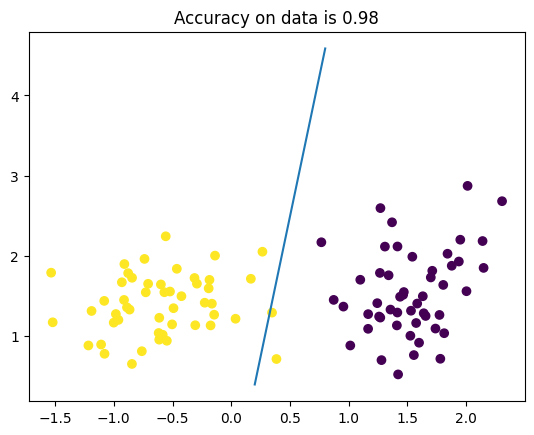

In [ ]:
losses, w = perceptron(X_train, y_train, batch_size=1)

# split off the bias
w = w[:-1]
b = w[-1]

plot(X_train, y_train, w, b)


Repeat the same training as above, but using batch_size=1,10,50,100.

Plot all the graphs and compare them. In addition, what is your optimal batch_size for this problem? why?

<font color='red'> Choice of batch_size = 10.

<font color='red'>Based on our experiments (test accuracies of 95 % for batch = 1 vs. 90 % for batch = 10, 50, 100), one might be tempted to choose batch = 1. However,it’s important to justify the choice in terms of both performance and efficiency:

<font color='red'>Comparable accuracy at far lower cost

<font color='red'>Both batch = 10 and batch = 50 converged in the same number of updates, yet each update for batch = 10 touches only 10 points instead of 50.

<font color='red'>This makes training with batch = 10 significantly faster in time.

<font color='red'>in pure stochastic updates (batch = 1) each step depends heavily on the single sampled point, which means a noisy path, and as we can see the highest iteration count.

<font color='red'>In contrast, batch = 10 averages over enough errors to yield a smooth, predictable boundary.
</font>

iterations number = 13


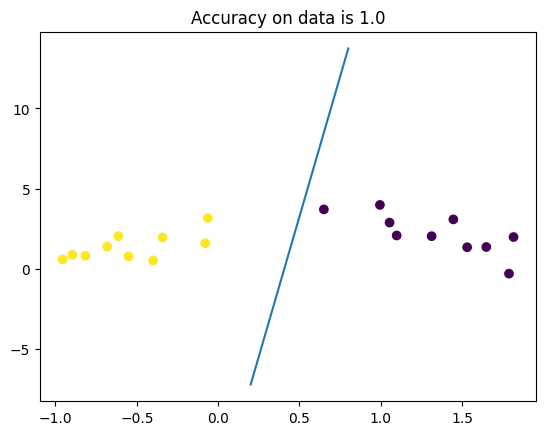

iterations number = 7


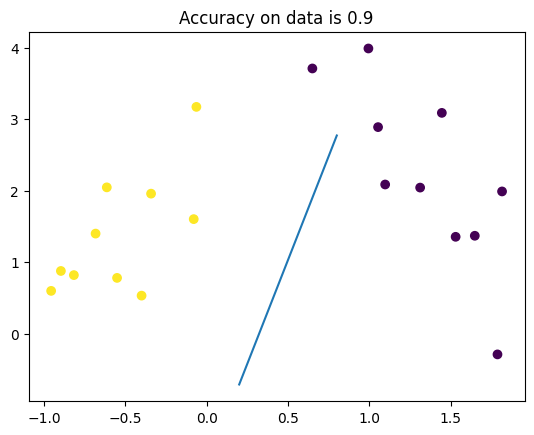

iterations number = 7


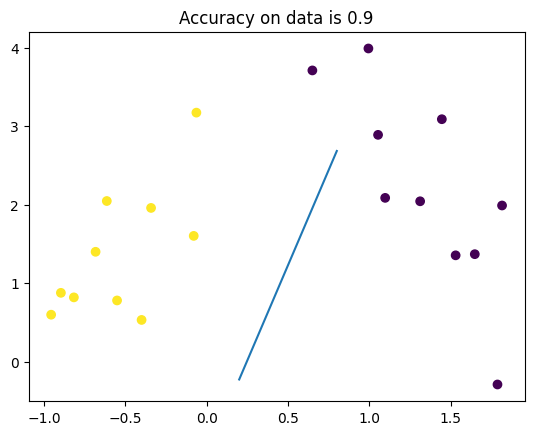

iterations number = 14


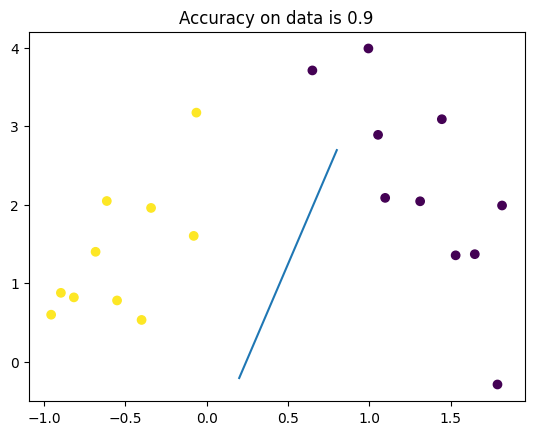

In [ ]:
for bs in [1, 10, 50, 100]:
    losses, w = perceptron(X_train, y_train, batch_size=bs)
    # split out bias
    w, b = w[:-1], w[-1]
    print(f"iterations number = {len(losses)}")
    plot(X_test, y_test, w, b)


Using the optimal batch_size you specified, print the final test accuracy.



In [ ]:
# Train on the train set with batch_size=1
losses, w = perceptron(X_train, y_train, batch_size=1)

# Split out w and bias
w, b = w[:-1], w[-1]

# Predict on the test set
preds = np.sign(X_test.dot(w) + b)

# Compute accuracy
acc = np.mean(preds == y_test)

print(f"Final test accuracy (batch_size=1): {acc*100:.2f}%")


Final test accuracy (batch_size=1): 95.00%


## Question 3 - Logistic regression

In this section you will build a classifier on a "toy" problem - Based on two grades, we determine if student passes the course or not.

import libraries and load dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('https://sharon.srworkspace.com/ml/datasets/hw2/exams2.csv', header=None)
df.head(3)

,0,1,2
0,35,78,0
1,30,44,0
2,36,73,0


Preprocess the data:
1. Convert dataset to numpy, make sure classes are {0,1}.
2. The grades are discrete values between 0-100. Make them continious by adding a noise $ϵ_i\sim\mathcal{N}(0,1)$ for each data point.

3. Split to temp & test (80-20, stratify, random_state=42)
4. Split the temp to train & validation (80-20, stratify, random_state=42)
5. Scale the data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

#convert to numpy
data = df.to_numpy()
grades = data[:, :2].astype(float)
labels = data[:,  2].astype(int)

#add Gaussian noise
grades+=np.random.normal(0, 1, grades.shape)

#split:temp/test
X_temp, X_test, y_temp, y_test = train_test_split(
        grades, labels, test_size=0.2, stratify=labels, random_state=42)

#split:train/val
X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42)

#scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


Implement the function `Logistic_Regression_via_GD(X, y, lr)`:
-	Input: the training data $X\in\mathbb{R}^{n\times d}$, a label vector $y\in\{0,1\}^n$ and learning rate parameter ‘lr’.
-	Output: The function computes the output vector ‘w’ (and ‘b’) which minimzes the logistic regression cost function on ‘X’ and ‘y’. <br/>

It should be done by implementing Gradient descent (with ‘lr’ as the learning rate) to solve logistic regression. Also, make sure to not run more than 3000 iterations. <br/>

Tip: The gradients may be large, you can use $\frac{1}{n}\nabla{L}$ (which is the true empirical loss' gradient)

In [ ]:

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def Logistic_Regression_via_GD(X, y, lr=0.1, lamda=0.0, max_iter=3000):
    n, d = X.shape  #n- num of samples , d- num of features
    w = np.zeros(d)  #initalize wiegths to zeroes
    b = 0.0  # initalize bias to zero
    #run gradient descent
    for _ in range(max_iter):
        z = np.dot(X,w) + b  #linear combination of labels and weights
        y_pred = sigmoid(z)  #segmoid for predictid probablites
        error= y_pred - y  #diffrence between predection and actual weights
        grad_w = (1/n) * (X.T @ error) + lamda * np.sign(w)
        grad_b = (1/n) * error.sum()
        w -= lr * grad_w
        b -= lr * grad_b
    return w, b   # return the learned weights and bias




The function 'predict' is already implemented for you. It gives a classification for a new sample (x) based on the sign of $w^\top x + b$. <br/>
The function currently returns {-1,+1}. <u>Modify this</u> to {0,1}

In [ ]:
def predict(w, b, X):
    return (sigmoid(X @ w + b) >= 0.5).astype(int)  #if sigmoid >=0.5 then class1 ,else class 0





Call `Logistic_Regression_via_GD(X,y,lr)`, where ‘X’ and ‘y’ are the training data and the corresponding labels. Use lr of 0.1 and print the accuracy on the test set.

In [ ]:
lamdas = np.linspace(0, 2, 21)  #alist of lambda values for test
val_acc = []  #validiation accuarcy for each lambda

for lam in lamdas:
    w, b = Logistic_Regression_via_GD(X_train, y_train, lr=0.1, lamda=lam)  #train logistic regression model with current lambda
    acc  = (predict(w, b, X_val) == y_val).mean() #predict on validation set and compute accuarcy
    val_acc.append(acc)
# choosing the lambda with the best validation accuarcy
best_lambda = lamdas[np.argmax(val_acc)]
print(f"Best λ from validation = {best_lambda:.2f}  (val-accuracy = {max(val_acc)*100:.2f}%)")
#combine training and validation data to retrain on full set
X_full  = np.vstack([X_train, X_val])
y_full  = np.hstack([y_train, y_val])

w, b = Logistic_Regression_via_GD(X_full, y_full, lr=0.1, lamda=best_lambda)
#evaluate accuarcy on the test set
test_acc = (predict(w, b, X_test) == y_test).mean()
print(f"Final Test Accuracy with λ={best_lambda:.2f}: {test_acc*100:.2f}%")


Best λ from validation = 0.00  (val-accuracy = 93.75%)
Final Test Accuracy with λ=0.00: 95.00%


Visualize the test data. As for now, it shows the scaled data.<br/>
Show the data and line of the original data ranges (x,y ranges in [0,100]).

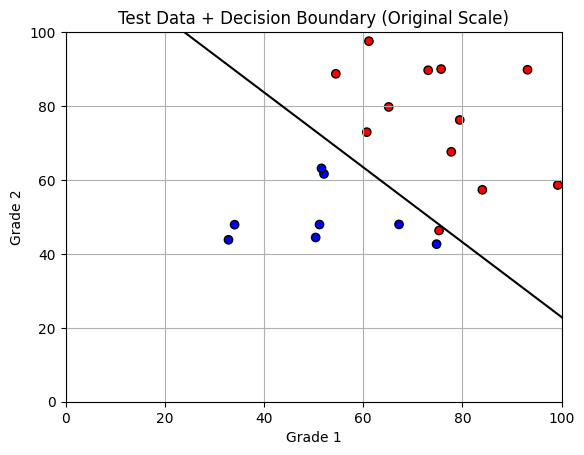

In [ ]:
import matplotlib.pyplot as plt

def plot(data_scaled, labels, w, b, scaler):
    data_orig = scaler.inverse_transform(data_scaled)

    plt.scatter(data_orig[:,0], data_orig[:,1],
                c=labels, cmap='bwr', edgecolors='k')

    # decision line in original [0,100] space
    x_vals    = np.linspace(0, 100, 200)
    x_scaled  = (x_vals - scaler.mean_[0]) / scaler.scale_[0]
    y_scaled  = -(w[0]*x_scaled + b) / w[1]
    y_vals    = y_scaled * scaler.scale_[1] + scaler.mean_[1]

    plt.plot(x_vals, y_vals, color='black')
    plt.xlim(0, 100); plt.ylim(0, 100)
    plt.xlabel("Grade 1"); plt.ylabel("Grade 2")
    plt.title("Test Data + Decision Boundary (Original Scale)")
    plt.grid(True); plt.show()

plot(X_test, y_test, w, b, scaler)


We now want to upgrade our model and add a regularization term. The loss will be

$$
L'=L+\lambda ||w||_1
$$

Adjust the implementation of `Logistic_Regression_via_GD` accordingly and add a hyperparameter named 'lamda'.

Plot a graph of the accuracy on the validation set as function of lamda. The range is up to your choice, but dont use a larger value than 2.

Final Test Accuracy using best lambda (0.01): 95.00%


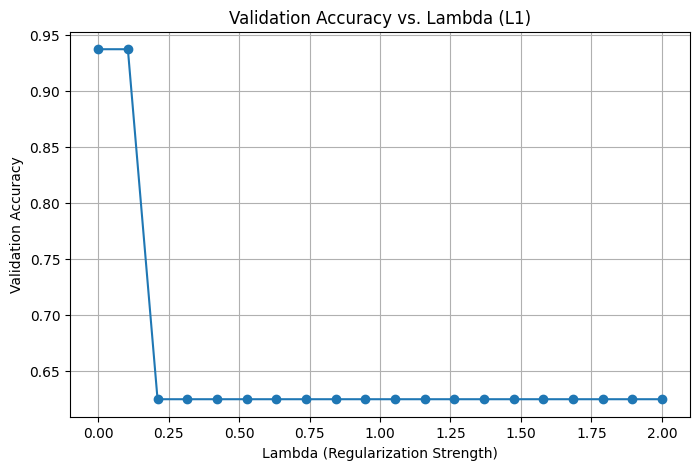

In [ ]:
import matplotlib.pyplot as plt

lamda_values = np.linspace(0, 2, 20)
val_accuracies = []
#print the best lambda
w, b = Logistic_Regression_via_GD(X_train, y_train, lr=0.1, lamda=0.01)
preds = predict(w, b, X_test)
accuracy = np.mean(preds == y_test)
print(f"Final Test Accuracy using best lambda ({0.01}): {accuracy * 100:.2f}%")


for lamda in lamda_values:
    w, b = Logistic_Regression_via_GD(X_train, y_train, lr=0.1, lamda=lamda)
    preds = predict(w, b, X_val)
    accuracy = np.mean(preds == y_val)
    val_accuracies.append(accuracy)


plt.figure(figsize=(8, 5))
plt.plot(lamda_values, val_accuracies, marker='o')
plt.xlabel('Lambda (Regularization Strength)')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs. Lambda (L1)')
plt.grid(True)
plt.show()


Using the best $\lambda$ obtained from your work, print the final test accuracy.

Answer the following questions:
1. Did we need lambda? Try to justify why the lambda you found is the best.
2. Generally speaking, when using the validation for tuning the best hyperparameter, is it guranteed it will be also the best for the test? Explain and show an example.

<font color='red'>q1)In our specific case, the best lambda found was very close to 0, and we saw that from the graph lambda vs accuarcy and we are seeing the when lambda getting bigger the accuarcy getting smaller, therefore we didnt need lambda because lambda didnt make any improvment in the performance. This indicates that our dataset was simple and didn't suffer significantly from overfitting, or our features were few enough that regularization actually harmed accuracy rather than improving it. Thus, we didn't needed regualization q2)No, it is not guaranteed that the lambda value which achieves the highest accuracy on the validation set will also achieve the highest accuracy on the test set. This is because the validation set is only a sample, and might not represent the real distribution of the data perfectly. Therefore, it's possible that a lambda that fits the validation set well may not generalize best to the test set.</font>

## Question 4 - SVM

Answer those questions here (in color) or in pdf

### First section

We will change the algorithm for Hard SVM by learning only from the samples with positive labels and ignoring samples with negative labelings. Hence, the optimization problem becomes:

$$\min \frac{1}{2}||w||^2\\
\text{s.t.} \forall i\in J_+, w^\top x_i+b\geq 1
$$

As $J_+$ is the set of positive labeled samples indexes.

a. Under the settings above, what will be the solution of w? Justify.
b. If we set b=0, meaning we remain only with $w^\top x_i\geq 1$, what is $\min_{i\in J_+} w^\top x_i?$

c. Let $w^*$ be the solution to the problem (b=0). We will classify new samples as:

$$
\hat{y}=\begin{cases}
1 & w^\top x\geq \min_{i\in J^+} w^\top x_i-ɛ \\
-1 & \text{otherwise}
\end{cases}
$$

For some small $ε>0$. Will this condition classify correctly all the training samples, both positive and negative? Justify

### Second section

Consider three distinct points $x_1,x_2∈R^d$ with labels $y_1=1, y_2=-1$.
Compute the hyperplane that Hard SVM will return on this data, i.e., give explicit expressions for w and b as functions of x1, x2.
Hint: convert the primal problem to the dual one and reduce it to a one variable problem.


### Third section

We define the SHOR loss function of finding linear seperators:

$$
L=\sum_{i=1}^n y_i*COST_0(\theta^\top x_i)+(1-y_i)*COST_1(\theta^\top x_i)
$$

Where:

<img src="https://srworkspace.com/sharon/ml/datasets/cost.png"/>

This loss will be zero if exactly two conditions hold true. Which two conditions gurantee this? Explain!

(i) For every sample with y_i=1, we have that $\theta^\top x_i\geq 0$

(ii) For every sample with y_i=0, we have that $\theta^\top x_i\leq 0$

(iii) For every sample with y_i=1, we have that $\theta^\top x_i\geq -1$

(iv) For every sample with y_i=1, we have that $\theta^\top x_i\geq 1$

## Question 5 - Bonus 8 pts

Recall the house prices dataset you have seen in class.
In this question, you will use another loss.

$$
L=\frac{1}{n}||Xw-y||_1=\frac{1}{n}\sum_{i=1}^n |w^\top x_i-y_i|
$$
This loss is more robust to outliers, since outliers affect linearly and not squared. However, w that minimizes this loss has no closed formula.

Implement here everything from scratch. Do not use an existing model to minimize the loss. Try to reach the best model you can

**Report** in your results: train and test results, plots, tuning (if you choose to), including any evidence your solution is good enough <br/>
<font color='red'>Report here about your choices and reasons (dealing with data, optimization methods)</font>


In [ ]:
# DO NOT CHANGE THIS CELL

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

data = pd.read_csv('https://sharon.srworkspace.com/ml/datasets/Toronto_rentals.csv')

X = data.iloc[:, :3]  #Bedroom, bathroom, den
y = data.iloc[:, -1].str.replace(r'[^\d.]', '', regex=True).astype('float') #Price

X = X.to_numpy()
y = y.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [ ]:
# Implement here

## How to Add Your Project to GitHub

Follow these steps to upload your Colab notebook and any associated files to a GitHub repository.

### Step 1: Install Git (if not already installed in your Colab environment)

Colab environments usually come with Git pre-installed. You can verify this by running `!git --version`.

In [1]:
import os

# Check Git version
!git --version

# Create a directory for your project (e.g., 'machine-learning-assignment')
project_name = 'machine-learning-assignment-2'
if not os.path.exists(project_name):
    os.makedirs(project_name)
    print(f"Created directory: {project_name}")
else:
    print(f"Directory '{project_name}' already exists.")

git version 2.34.1
Created directory: machine-learning-assignment-2


### Step 2: Save your Colab Notebook to the Project Directory

First, you need to download your current Colab notebook as an `.ipynb` file. Go to `File > Download > Download .ipynb` in the Colab menu. Then, upload this downloaded file to the project directory you just created. You can do this by clicking the folder icon on the left panel, navigating to your `machine-learning-assignment-2` directory, and then clicking the 'Upload' icon.

Alternatively, you can save the current notebook directly to the content directory if you connect to your Google Drive:

```python
# This part assumes you want to save the current notebook to Google Drive
# and then access it from the Colab environment.
# Make sure your notebook is saved to your Google Drive first.

# from google.colab import drive
# drive.mount('/content/drive')

# You would then copy your .ipynb file from drive to your project directory
# Example: !cp '/content/drive/My Drive/Colab Notebooks/Your_Notebook_Name.ipynb' './machine-learning-assignment-2/'
```

For simplicity, let's assume you've manually downloaded and uploaded the notebook (e.g., named `assignment_2.ipynb`) into the `machine-learning-assignment-2` folder.

### Step 7: Verify on GitHub

Refresh your GitHub repository page in your browser. You should now see your `assignment_2.ipynb`, `README.md`, and `.gitignore` files uploaded.